# 1. Import Necessary libraries

In [15]:
import tensorflow as tf
import keras
from matplotlib import pyplot as plt
import numpy as np

# 2. Import Data

In [3]:
(X_train, _), (X_test, _) = keras.datasets.mnist.load_data(path="mnist.npz")

In [4]:
X_train.shape,X_test.shape

((60000, 28, 28), (10000, 28, 28))

# 3. Data Preparation

### 3.1 Add the Channel

In [8]:
X_train = X_train.reshape(60000, 28, 28,1)
X_test = X_test.reshape(10000, 28, 28,1)

In [9]:
X_train.shape,X_test.shape

((60000, 28, 28, 1), (10000, 28, 28, 1))

### 3.2 Normalize

In [10]:
X_train = X_train/255.0
X_test = X_test/255.0

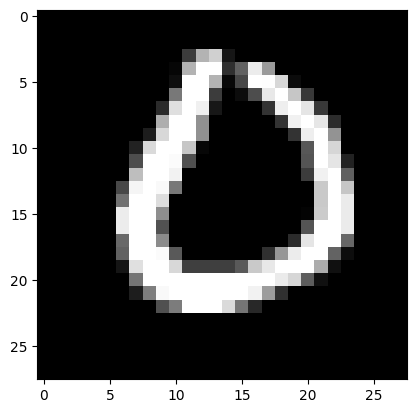

In [14]:
plt.imshow(X_train[2500],cmap = "grey")

### 3.3 Add  Noise

In [29]:
X_train_noise = X_train + 0.3 * np.random.normal(loc=0.0, scale=1.0, size=X_train.shape)
X_test_noise  = X_test + 0.3 * np.random.normal(loc=0.0, scale=1.0, size=X_test.shape)

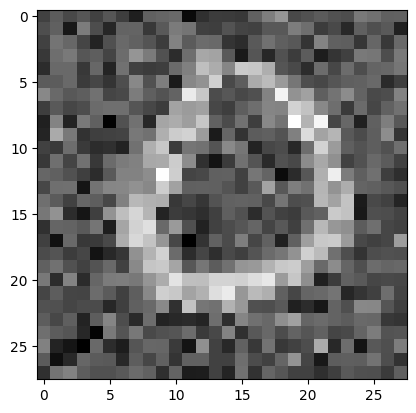

In [30]:
plt.imshow(X_train_noise[2500],cmap = "grey")

In [21]:
X_train_noise.max(),X_train_noise.min()

(np.float64(2.0487085716615994), np.float64(-1.1322799534471297))

### 3.4 Add the Clip

In [34]:
X_train_clipped = np.clip(a = X_train_noise,a_min=0., a_max=1.) # i will have positve values
X_test_clipped  = np.clip(a = X_test_noise,a_min=0., a_max=1.)

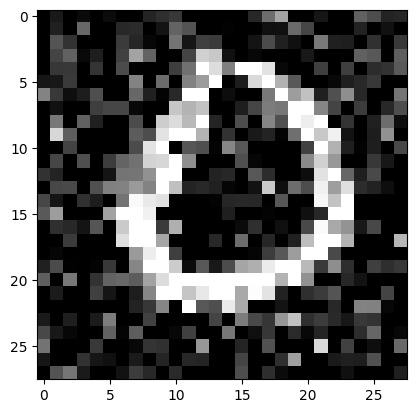

In [35]:
plt.imshow(X_train_clipped[2500],cmap = "grey")

# 4. Model Building

In [46]:
from keras import Sequential
from keras.layers import Conv2D,MaxPool2D,UpSampling2D

import warnings
warnings.filterwarnings("ignore")

In [49]:
model = Sequential()
#Encoder - compress the info
model.add(Conv2D(filters = 32,kernel_size = (3,3),strides=(1, 1),padding='same',activation="relu",input_shape =(28,28,1)))
model.add(MaxPool2D(pool_size=(2, 2)))
model.add(Conv2D(filters = 8,kernel_size = (3,3),strides=(1, 1),padding='same',activation="relu"))
model.add(MaxPool2D(pool_size=(2, 2)))

#Decoder - Expands
model.add(Conv2D(filters = 8,kernel_size = (3,3),strides=(1, 1),padding='same',activation="relu"))
model.add(MaxPool2D(pool_size=(2, 2)))
model.add(Conv2D(filters = 8,kernel_size = (3,3),strides=(1, 1),padding='same',activation="relu"))
model.add(UpSampling2D(size=(2, 2)))
model.add(Conv2D(filters = 32,kernel_size = (3,3),strides=(1, 1),padding='same',activation="relu"))
model.add(UpSampling2D(size=(2, 2)))
model.add(Conv2D(filters = 1,kernel_size = (3,3),strides=(1, 1),padding='same',activation="relu"))

model.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_11 (Conv2D)                   │ (None, 28, 28, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_8 (MaxPooling2D)       │ (None, 14, 14, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_12 (Conv2D)                   │ (None, 14, 14, 8)           │           2,312 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_9 (MaxPooling2D)       │ (None, 7, 7, 8)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_13 (Conv2D)                   │ (None, 7, 7, 8)             │             584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ up_sampling2d_3 (UpSampling2D)       │ (None, 14, 14, 8)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_14 (Conv2D)                   │ (None, 14, 14, 32)          │           2,336 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ up_sampling2d_4 (UpSampling2D)       │ (None, 28, 28, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_15 (Conv2D)                   │ (None, 28, 28, 1)           │             289 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 5,841 (22.82 KB)

 Trainable params: 5,841 (22.82 KB)

 Non-trainable params: 0 (0.00 B)

# 5. Model Compilation

In [51]:
model.compile(optimizer='adam', loss="mean_squared_error",metrics=["accuracy"])

# 6. Model Training

In [52]:
model.fit(x=X_train_clipped, y=X_train, batch_size=32, epochs=5, validation_data=(X_test,X_test_clipped))

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 23s 12ms/step - accuracy: 0.8132 - loss: 0.0132 - val_accuracy: 0.4670 - val_loss: 0.0521
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 43s 13ms/step - accuracy: 0.8144 - loss: 0.0086 - val_accuracy: 0.4676 - val_loss: 0.0507
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 21s 11ms/step - accuracy: 0.8145 - loss: 0.0079 - val_accuracy: 0.4678 - val_loss: 0.0504
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 35s 8ms/step - accuracy: 0.8146 - loss: 0.0075 - val_accuracy: 0.4680 - val_loss: 0.0501
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 21s 11ms/step - accuracy: 0.8147 - loss: 0.0073 - val_accuracy: 0.4680 - val_loss: 0.0503


# 7. Model Evaluation

In [53]:
model.evaluate(X_test_clipped,X_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8135 - loss: 0.0072


[0.00722334673628211, 0.8134665489196777]

# 8. Model Prediction

In [54]:
y_pred = model.predict(X_test_clipped)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step


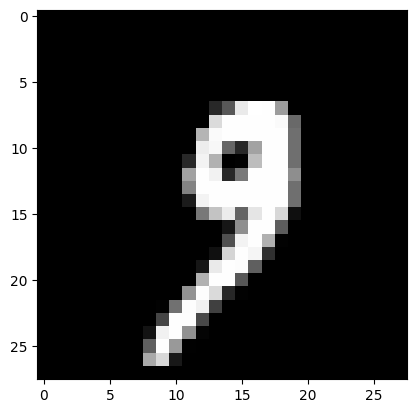

In [59]:
plt.imshow(X_test[1000],cmap = "grey")

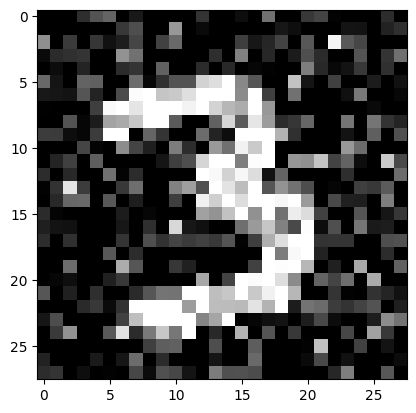

In [61]:
plt.imshow(X_test_clipped[500],cmap = "grey")

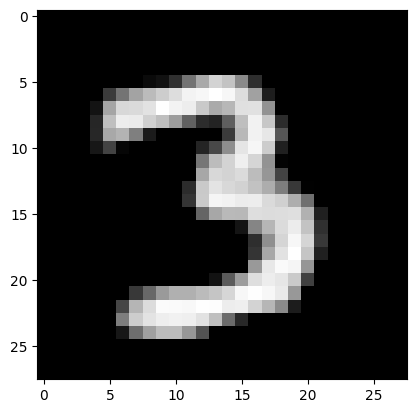

In [62]:
#plt.imshow(X_test[1000],cmap = "grey")
plt.imshow(y_pred[500],"grey")

## 9. Save the model

In [63]:
model.save("denoising.h5")

## THE END